In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

In [111]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/temperature2m_ERA5-Land.nc'
temp_ERA5_Land = xr.open_dataset(filepath)
temp_ERA5_Land = temp_ERA5_Land.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5_Land = temp_ERA5_Land.reindex(lat=list(reversed(temp_ERA5_Land.lat)))

In [ ]:
season='JJA'
# Compute JJA trend over land for ERA5-Land
# Regional average, Arctic excluding Greenland (lons > 300)
temp_ERA5_Arctic_land = functions.computeWeightedMean(temp_ERA5_Land)
# Select season
temp_ERA5_season = temp_ERA5_Arctic_land.sel(time=temp_ERA5_Arctic_land.time.dt.season==season)
# Annual season mean
temp_ERA5_season_annual = temp_ERA5_season.groupby(temp_ERA5_season.time.dt.year).mean('time')
# Save file for later use
temp_ERA5_season_annual.to_netcdf(rpath+'temperature2m_ERA5_JJA_annual.nc')

In [114]:
# Regional average, Arctic excluding Greenland (lons > 300)
temp_ERA5_Arctic_land = functions.computeWeightedMean(temp_ERA5_Land)
# Annual mean
temp_ERA5_season_annual = temp_ERA5_Arctic_land.groupby(temp_ERA5_Arctic_land.time.dt.year).mean('time')
# Save file for later use
temp_ERA5_season_annual.to_netcdf(rpath+'temperature2m_ERA5_annual.nc')

In [5]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/data_stream-moda.nc'
SM_ERA5 = xr.open_dataset(filepath)
SM_ERA5 = SM_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
SM_ERA5_1970_2025 = SM_ERA5.sel(time=slice('1970-01-01','2025-09-01'))
SM_ERA5_1970_2025 = SM_ERA5_1970_2025.reindex(lat=list(reversed(SM_ERA5_1970_2025.lat)))
SM_ERA5_1970_2025.to_netcdf(rpath+'SM_ERA5_1970_2025.nc')

In [6]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'

SM_WM = xr.open_dataset(filepath)
SM_WM_1970_2016 = SM_WM.sel(time=slice('1970-01-01','2016-12-31'),lat=slice(59,90))
SM_WM_1970_2016_masked = SM_WM_1970_2016.where(SM_WM_1970_2016['mrsos'] < 1000)
SM_WM_1970_2016_masked = SM_WM_1970_2016_masked.drop_vars('time_bounds')
SM_WM_1970_2016_masked.to_netcdf(rpath+'SM_WangMao_1970_2016_masked.nc')

In [3]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025.nc')

In [4]:
SM_WM = xr.open_dataset(rpath+'SM_WangMao_1970_2016_masked.nc')

In [5]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc'
CERES = xr.open_dataset(filepath)

In [6]:
# Get land mask for CERES data

# Get land mask for NorESM2
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/LANDFRAC_piClim.nc'
landfrac = xr.open_dataarray(filepath)
landmask = landfrac.isel(time=0)

# Interpolate to CERES data
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
landmask_CERES = landmask_CERES.where(landmask_CERES>=0)
landmask_CERES = landmask_CERES.fillna(0)

In [15]:
SM_ERA5_trends_2002_2024 = xr.open_dataset(rpath+'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024.nc')
SM_ERA5_trends_2002_2024 = SM_ERA5_trends_2002_2024.rename({'latitude':'lat', 'longitude':'lon'})
SM_ERA5_trends_2002_2024 = SM_ERA5_trends_2002_2024.reindex(lat=list(reversed(SM_ERA5_trends_2002_2024.lat)))
SM_ERA5_trends_2002_2024.to_netcdf(rpath+'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024_correct.nc')

In [13]:
Arctic_limit=60
season='JJA'

# Compute JJA trend over land for CERES
# Regional average, Arctic land excluding Greenland (lons > 300)
CERES_Arctic = functions.computeWeightedMeanMasked(CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask_CERES.sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)))
# Select season
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create linear regression
CERES_slope, CERES_intercept, CERES_r_value, CERES_p_value, CERES_std_err = stats.linregress(CERES_season_annual.year, CERES_season_annual.values)

# Compute JJA trend over land for ERA5-Land
timeslice_trend=slice(1985,2024)
ref_timeslice=slice(1970,2000)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.07 m = 70 kg/m2)
SM_ERA5_converted = SM_ERA5['swvl1']*70
# Regional average, Arctic excluding Greenland (lons > 300)
SM_ERA5_Arctic = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=slice(0,300)))
# Select season
SM_ERA5_season = SM_ERA5_Arctic.sel(time=SM_ERA5_Arctic.time.dt.season==season)
# Annual season mean
SM_ERA5_season_annual = SM_ERA5_season.groupby(SM_ERA5_season.time.dt.year).mean('time')
# Reference period mean
SM_ERA5_ref_mean = SM_ERA5_season_annual.sel(year=ref_timeslice).mean('year')
# Create linear regression
SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_r_value, SM_ERA5_p_value, SM_ERA5_std_err = stats.linregress(SM_ERA5_season_annual.sel(year=timeslice_trend).year, (SM_ERA5_season_annual.sel(year=timeslice_trend)-SM_ERA5_ref_mean).values)

# Compute JJA trend over land for Wang & Mao dataset
# Regional average, Arctic excluding Greenland (lons > 300)
timeslice_trend=slice(1985,2016)
ref_timeslice=slice(1970,2000)
SM_WM_Arctic = functions.computeWeightedMean(SM_WM['mrsos'].sel(lon=slice(0,300)))
# Select season
SM_WM_season = SM_WM_Arctic.sel(time=SM_WM_Arctic.time.dt.season==season)
# Annual season mean
SM_WM_season_annual = SM_WM_season.groupby(SM_WM_season.time.dt.year).mean('time')
# Reference period mean
SM_WM_ref_mean = SM_WM_season_annual.sel(year=ref_timeslice).mean('year')
# Create linear regression
SM_WM_slope, SM_WM_intercept, SM_WM_r_value, SM_WM_p_value, SM_WM_std_err = stats.linregress(SM_WM_season_annual.sel(year=timeslice_trend).year, (SM_WM_season_annual.sel(year=timeslice_trend)-SM_WM_ref_mean).values)


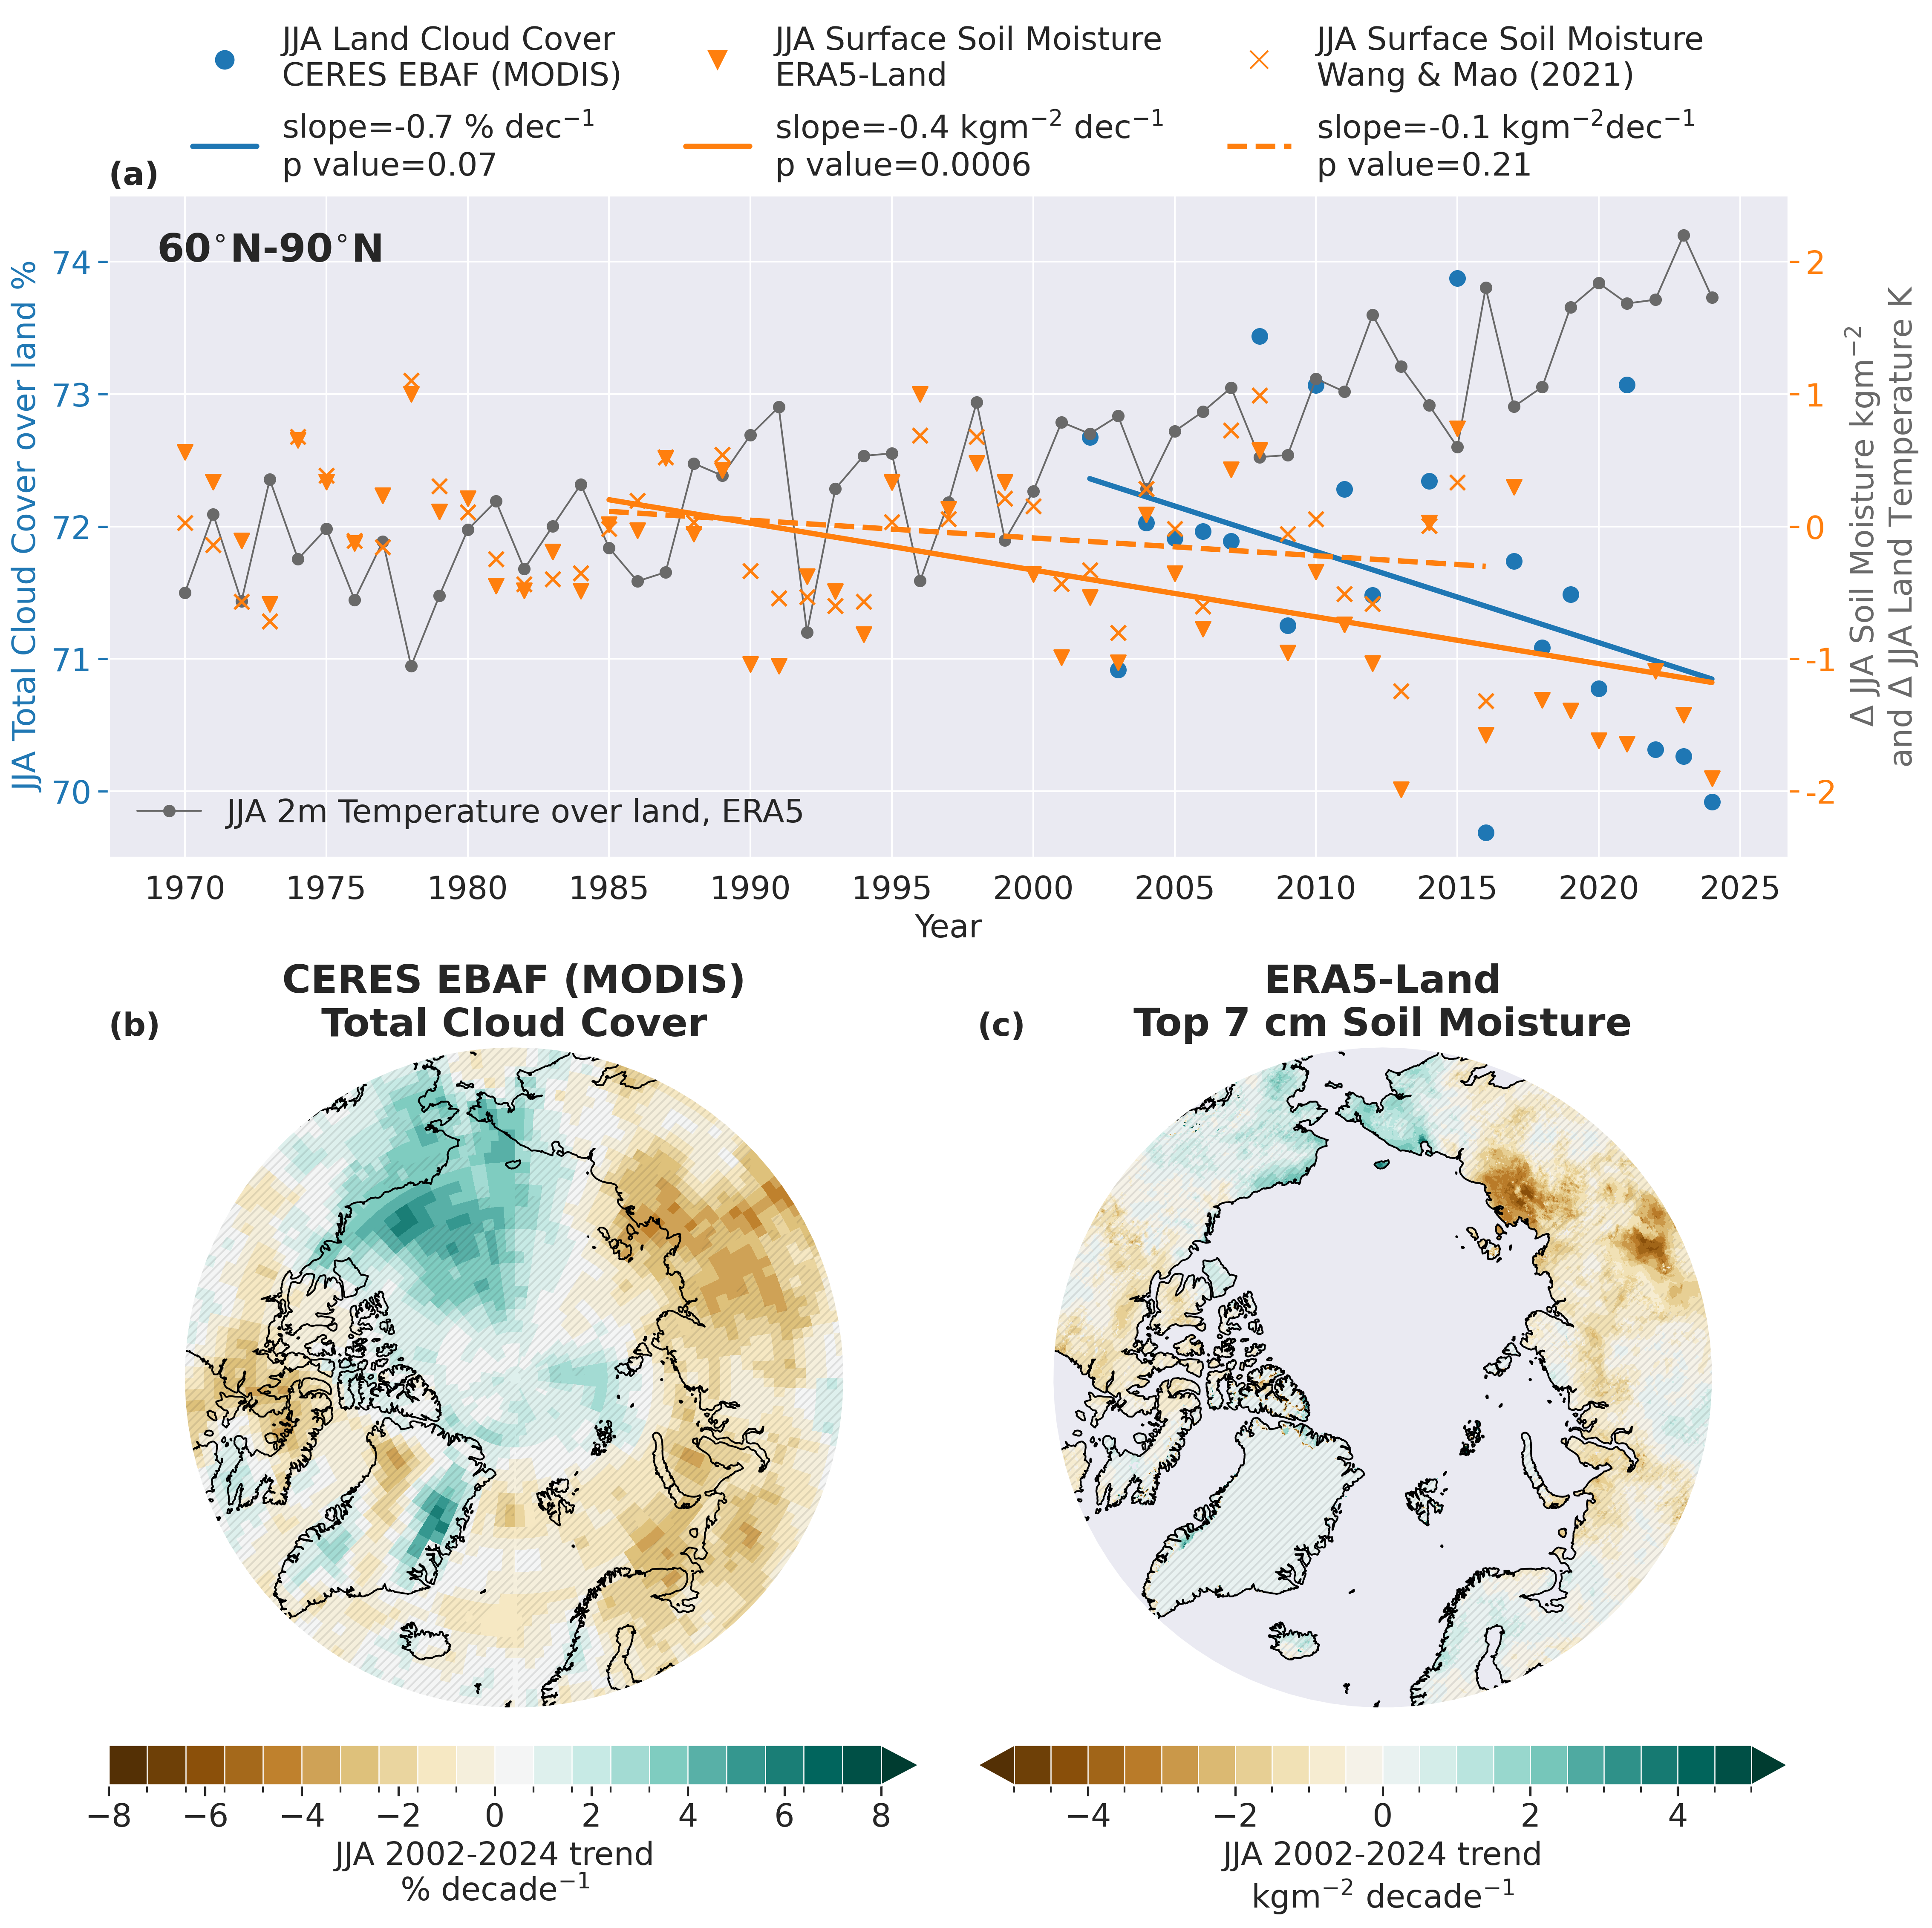

In [14]:
sns.set_theme()
labels = [['(a)','(a)'],['(b)','(c)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 15),dpi=300,constrained_layout=True)
# Remove axis from map plots
for label in labels[1]:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Orthographic(0, 90))
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Orthographic(0, 90))


# Row 1: trends
ax = axs['(a)']
ax2 = ax.twinx()

temp_ERA5_JJA = xr.open_dataset(rpath+'temperature2m_ERA5_JJA_annual.nc')
temp_ref_mean = temp_ERA5_JJA['t2m'].sel(year=slice(1970,2000)).mean('year')
ax2.plot(np.arange(1970,2025,1),(temp_ERA5_JJA['t2m'].sel(year=slice(1970,2024))-temp_ref_mean),
         label = 'JJA 2m Temperature over land, ERA5',
         color='dimgrey', linewidth=1, marker='o',zorder=0)

CERES_color='tab:blue'
for i in range(0, len(CERES_season_annual.year)):
    ax.scatter(CERES_season_annual.year[i], CERES_season_annual.isel(year=i), color=CERES_color, s=70)
ax.plot(CERES_season_annual.year, CERES_intercept+CERES_slope*CERES_season_annual.year, color=CERES_color, lw=3)

SM_color = 'tab:orange'
timeslice=slice(1970,2024)
timeslice_trend=slice(1985,2024)
for i in range(0, len(SM_ERA5_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_ERA5_season_annual.sel(year=timeslice).year[i], (SM_ERA5_season_annual.sel(year=timeslice)-SM_ERA5_ref_mean).isel(year=i), color=SM_color, marker='v',s=70)
ax2.plot(SM_ERA5_season_annual.sel(year=timeslice_trend).year, SM_ERA5_intercept+SM_ERA5_slope*SM_ERA5_season_annual.sel(year=timeslice_trend).year, color=SM_color, lw=3)

timeslice=slice(1970,2016)
timeslice_trend=slice(1985,2016)
for i in range(0, len(SM_WM_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_WM_season_annual.sel(year=timeslice).year[i], (SM_WM_season_annual.sel(year=timeslice)-SM_WM_ref_mean).isel(year=i), color=SM_color, marker='x', s=70)
ax2.plot(SM_WM_season_annual.sel(year=timeslice_trend).year, SM_WM_intercept+SM_WM_slope*SM_WM_season_annual.sel(year=timeslice_trend).year, color=SM_color, ls='--',lw=3)

legend_elements = [Line2D([0], [0], marker='o',color='None',mec=CERES_color,mfc=CERES_color, markersize=10, label='JJA Land Cloud Cover\nCERES EBAF (MODIS)'),
                   Line2D([0], [0], color=CERES_color, lw=3, linestyle='-', label='slope='+str(np.round(CERES_slope*10,1))+' % dec$^{-1}$\np value='+str(np.round(CERES_p_value,2))),
                   Line2D([0], [0], marker='v',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nERA5-Land'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='-', label='slope='+str(np.round(SM_ERA5_slope*10,1))+' kgm$^{-2}$ dec$^{-1}$\np value='+str(np.round(SM_ERA5_p_value,4))),
                   Line2D([0], [0], marker='x',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nWang & Mao (2021)'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='--', label='slope='+str(np.round(SM_WM_slope*10,1))+' kgm$^{-2} $dec$^{-1}$\np value='+str(np.round(SM_WM_p_value,2))),]

years = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=18)

ax.text(1969, 74, '60$^{\circ}$N-90$^{\circ}$N', fontsize=22, fontweight='bold')

ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('JJA Total Cloud Cover over land %', fontsize=18)
ax.yaxis.label.set_color(CERES_color)
ax.tick_params(axis='y', colors=CERES_color)
ax.set_ylim([69.5, 74.5])
yticks1 = [70, 71, 72, 73, 74]
ax.set_yticks(yticks1)
ax.set_yticklabels(yticks1, fontsize=18)

ax2.set_xlabel('Year')
ax2.set_ylabel('$\Delta$ JJA Soil Moisture kgm$^{-2}$\nand $\Delta$ JJA Land Temperature K',fontsize=18)
ax2.yaxis.label.set_color('dimgrey')
ax2.tick_params(axis='y', colors=SM_color)
ax2.set_ylim([-2.5, 2.5])
yticks2 = [-2, -1, 0, 1, 2]
ax2.set_yticks(yticks2)
ax2.set_yticklabels(yticks2, fontsize=18)
ax2.grid()

ax.legend(handles=legend_elements, ncols=3, loc='upper center', 
    bbox_to_anchor=(0.5, 1.3),frameon=False, fontsize=18)

ax2.legend(loc='lower left',frameon=False, fontsize=18)

# Row 2: spatial trends
for ax, title, unit, file, limit in zip([ax3, ax4], 
                                  ['CERES EBAF (MODIS)\nTotal Cloud Cover', 'ERA5-Land\nTop 7 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['CERES_trends_JJA.nc', 'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024_correct.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend'].T*10 # multiply by 10 to get trend per decade
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T > significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'/', hatch_density*'/'])    
    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2002-2024 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')

#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.png')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.pdf')

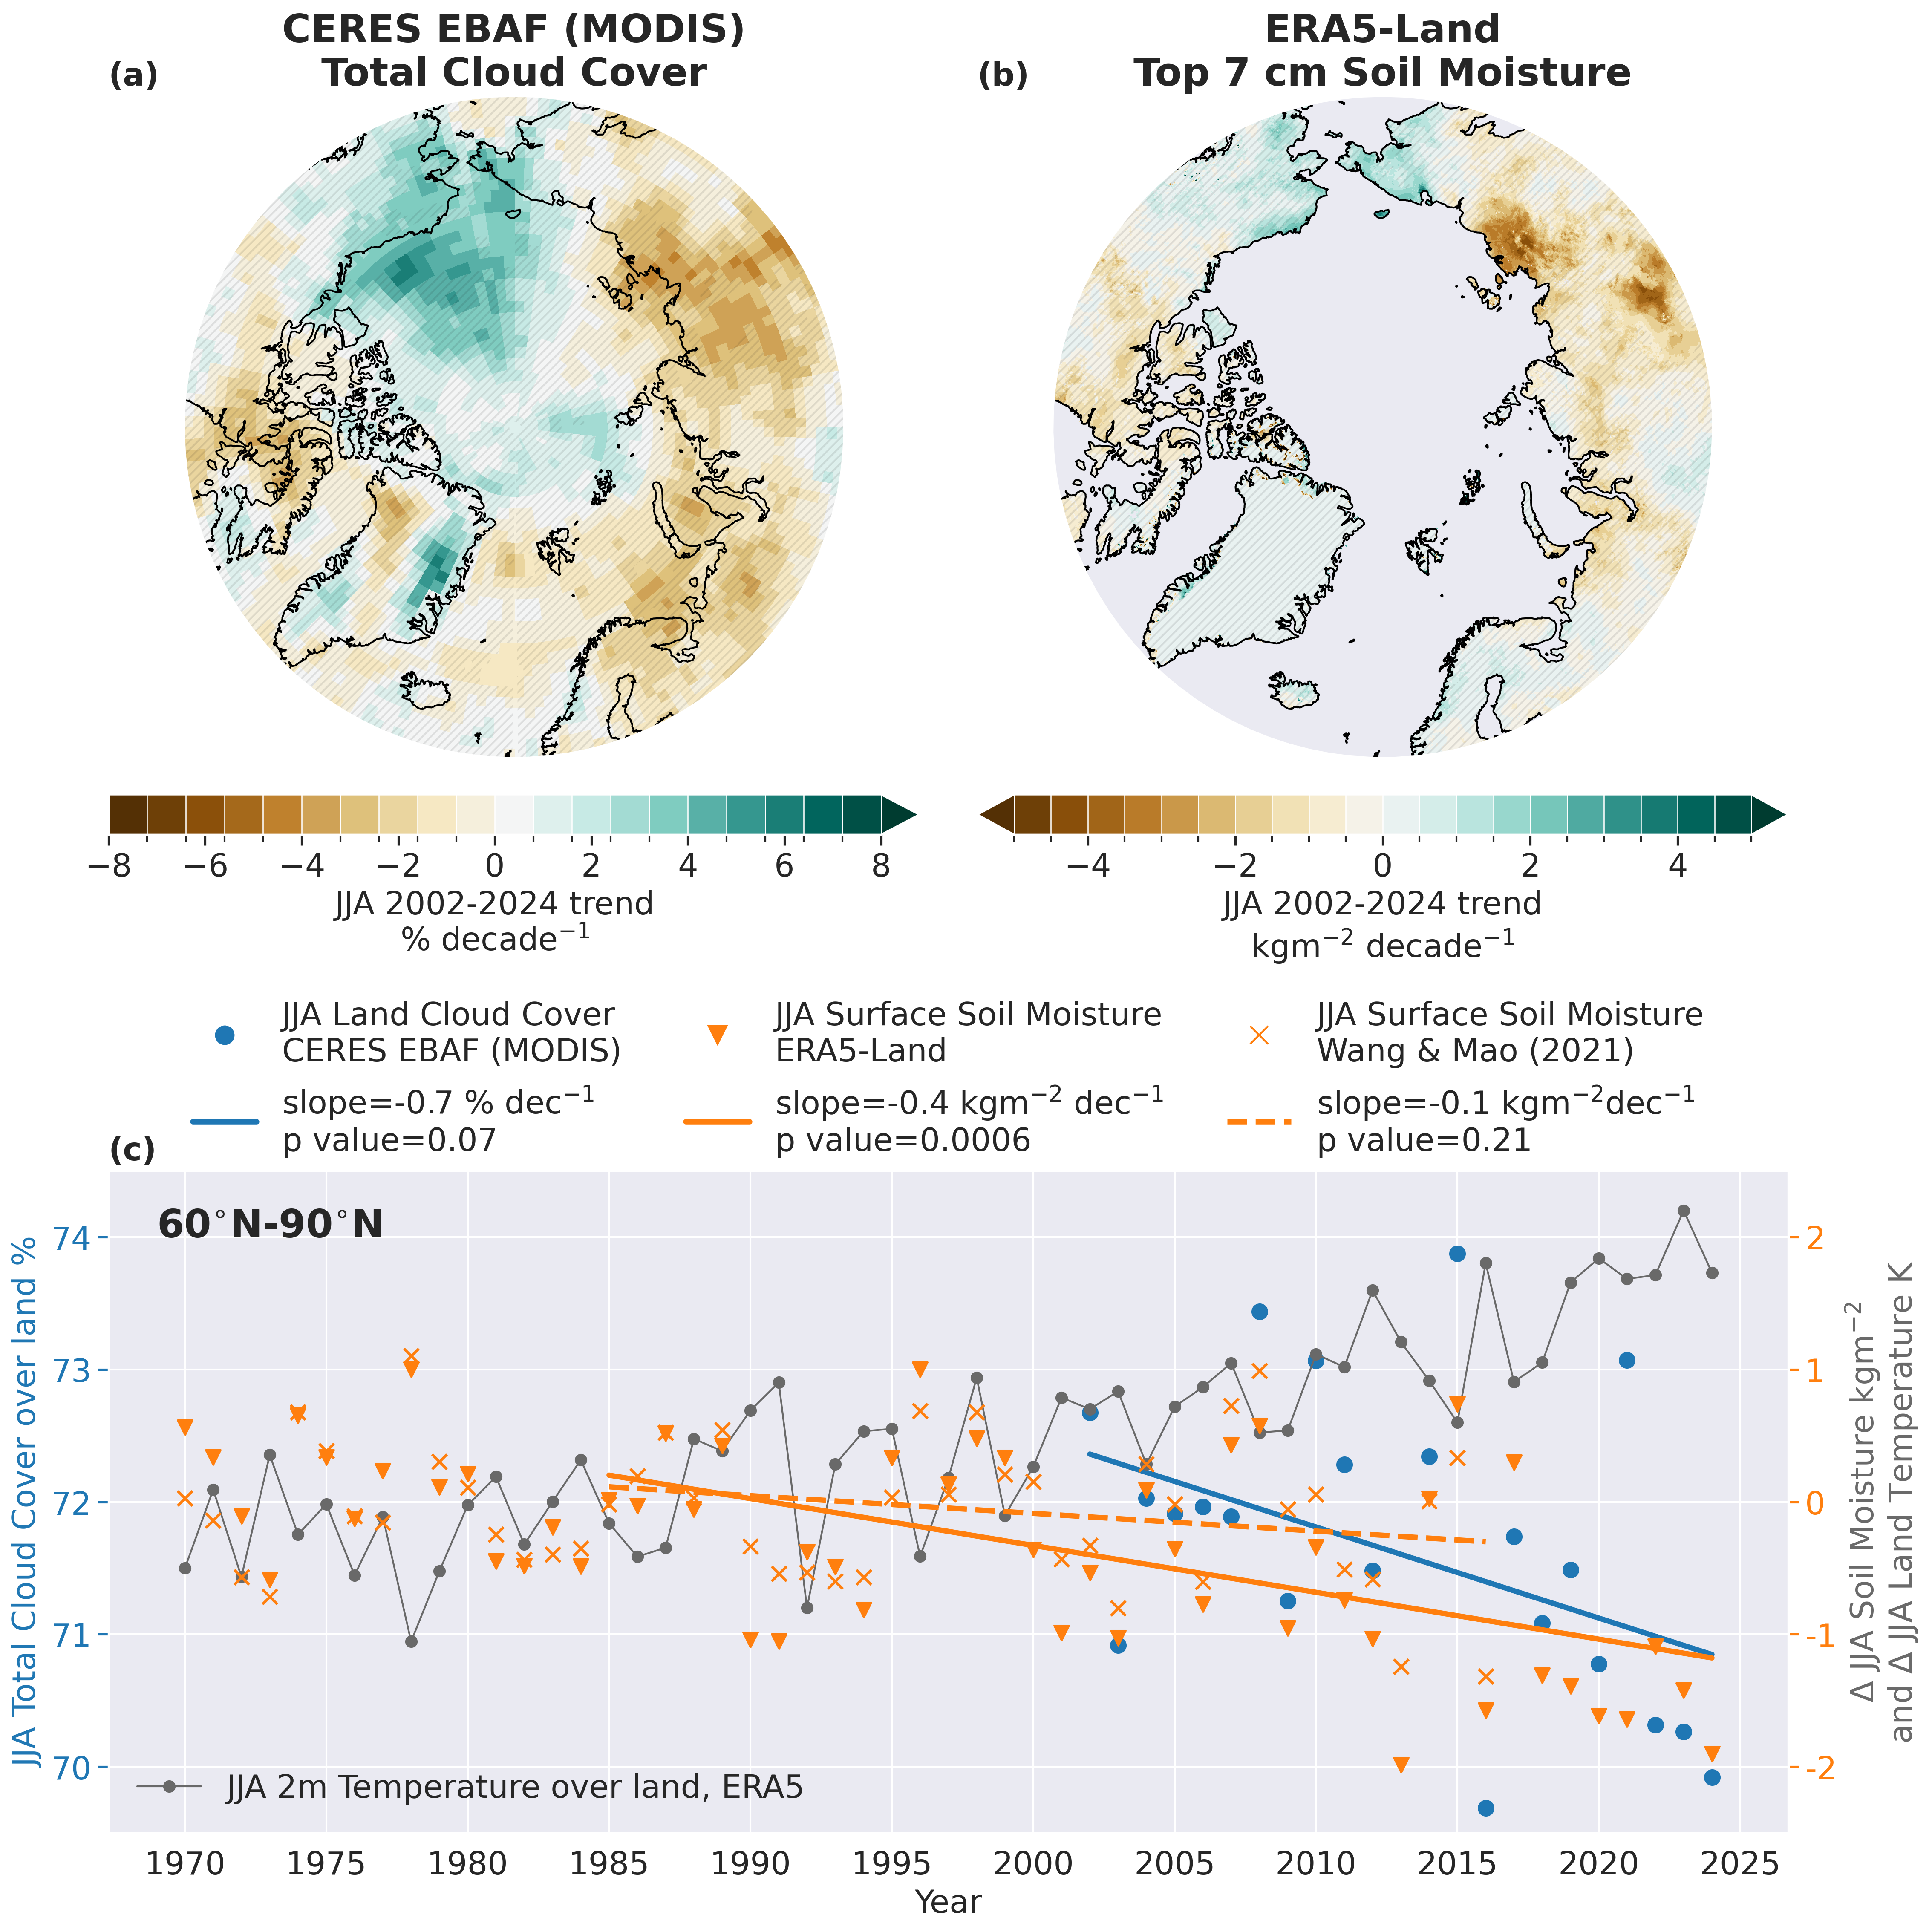

In [15]:
sns.set_theme()
labels = [['(a)','(b)'],['(c)','(c)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 15),dpi=300,constrained_layout=True)
# Remove axis from map plots
for label in labels[0]:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax3 = fig.add_subplot(2, 2, 1, projection=ccrs.Orthographic(0, 90))
ax4 = fig.add_subplot(2, 2, 2, projection=ccrs.Orthographic(0, 90))


# Row |: spatial trends
for ax, title, unit, file, limit in zip([ax3, ax4], 
                                  ['CERES EBAF (MODIS)\nTotal Cloud Cover', 'ERA5-Land\nTop 7 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['CERES_trends_JJA.nc', 'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024_correct.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend'].T*10 # multiply by 10 to get trend per decade
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T > significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'/', hatch_density*'/'])    
    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2002-2024 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Row 2: trends
ax = axs['(c)']
ax2 = ax.twinx()

temp_ERA5_JJA = xr.open_dataset(rpath+'temperature2m_ERA5_JJA_annual.nc')
temp_ref_mean = temp_ERA5_JJA['t2m'].sel(year=slice(1970,2000)).mean('year')
ax2.plot(np.arange(1970,2025,1),(temp_ERA5_JJA['t2m'].sel(year=slice(1970,2024))-temp_ref_mean),
         label = 'JJA 2m Temperature over land, ERA5',
         color='dimgrey', linewidth=1, marker='o',zorder=0)

CERES_color='tab:blue'
for i in range(0, len(CERES_season_annual.year)):
    ax.scatter(CERES_season_annual.year[i], CERES_season_annual.isel(year=i), color=CERES_color, s=70)
ax.plot(CERES_season_annual.year, CERES_intercept+CERES_slope*CERES_season_annual.year, color=CERES_color, lw=3)

SM_color = 'tab:orange'
timeslice=slice(1970,2024)
timeslice_trend=slice(1985,2024)
for i in range(0, len(SM_ERA5_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_ERA5_season_annual.sel(year=timeslice).year[i], (SM_ERA5_season_annual.sel(year=timeslice)-SM_ERA5_ref_mean).isel(year=i), color=SM_color, marker='v',s=70)
ax2.plot(SM_ERA5_season_annual.sel(year=timeslice_trend).year, SM_ERA5_intercept+SM_ERA5_slope*SM_ERA5_season_annual.sel(year=timeslice_trend).year, color=SM_color, lw=3)

timeslice=slice(1970,2016)
timeslice_trend=slice(1985,2016)
for i in range(0, len(SM_WM_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_WM_season_annual.sel(year=timeslice).year[i], (SM_WM_season_annual.sel(year=timeslice)-SM_WM_ref_mean).isel(year=i), color=SM_color, marker='x', s=70)
ax2.plot(SM_WM_season_annual.sel(year=timeslice_trend).year, SM_WM_intercept+SM_WM_slope*SM_WM_season_annual.sel(year=timeslice_trend).year, color=SM_color, ls='--',lw=3)

legend_elements = [Line2D([0], [0], marker='o',color='None',mec=CERES_color,mfc=CERES_color, markersize=10, label='JJA Land Cloud Cover\nCERES EBAF (MODIS)'),
                   Line2D([0], [0], color=CERES_color, lw=3, linestyle='-', label='slope='+str(np.round(CERES_slope*10,1))+' % dec$^{-1}$\np value='+str(np.round(CERES_p_value,2))),
                   Line2D([0], [0], marker='v',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nERA5-Land'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='-', label='slope='+str(np.round(SM_ERA5_slope*10,1))+' kgm$^{-2}$ dec$^{-1}$\np value='+str(np.round(SM_ERA5_p_value,4))),
                   Line2D([0], [0], marker='x',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nWang & Mao (2021)'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='--', label='slope='+str(np.round(SM_WM_slope*10,1))+' kgm$^{-2} $dec$^{-1}$\np value='+str(np.round(SM_WM_p_value,2))),]

#plt.grid()
#ax.set_title('Latitudes > 60$^{\circ}$N', fontsize=22, fontweight='bold')
years = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=18)

ax.text(1969, 74, '60$^{\circ}$N-90$^{\circ}$N', fontsize=22, fontweight='bold')

ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('JJA Total Cloud Cover over land %', fontsize=18)
ax.yaxis.label.set_color(CERES_color)
ax.tick_params(axis='y', colors=CERES_color)
ax.set_ylim([69.5, 74.5])
yticks1 = [70, 71, 72, 73, 74]
ax.set_yticks(yticks1)
ax.set_yticklabels(yticks1, fontsize=18)

ax2.set_xlabel('Year')
ax2.set_ylabel('$\Delta$ JJA Soil Moisture kgm$^{-2}$\nand $\Delta$ JJA Land Temperature K',fontsize=18)
ax2.yaxis.label.set_color('dimgrey')
ax2.tick_params(axis='y', colors=SM_color)
ax2.set_ylim([-2.5, 2.5])
yticks2 = [-2, -1, 0, 1, 2]
ax2.set_yticks(yticks2)
ax2.set_yticklabels(yticks2, fontsize=18)
ax2.grid()

ax.legend(handles=legend_elements, ncols=3, loc='upper center', 
    bbox_to_anchor=(0.5, 1.3),frameon=False, fontsize=18)

ax2.legend(loc='lower left',frameon=False, fontsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')

#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.png')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.pdf')

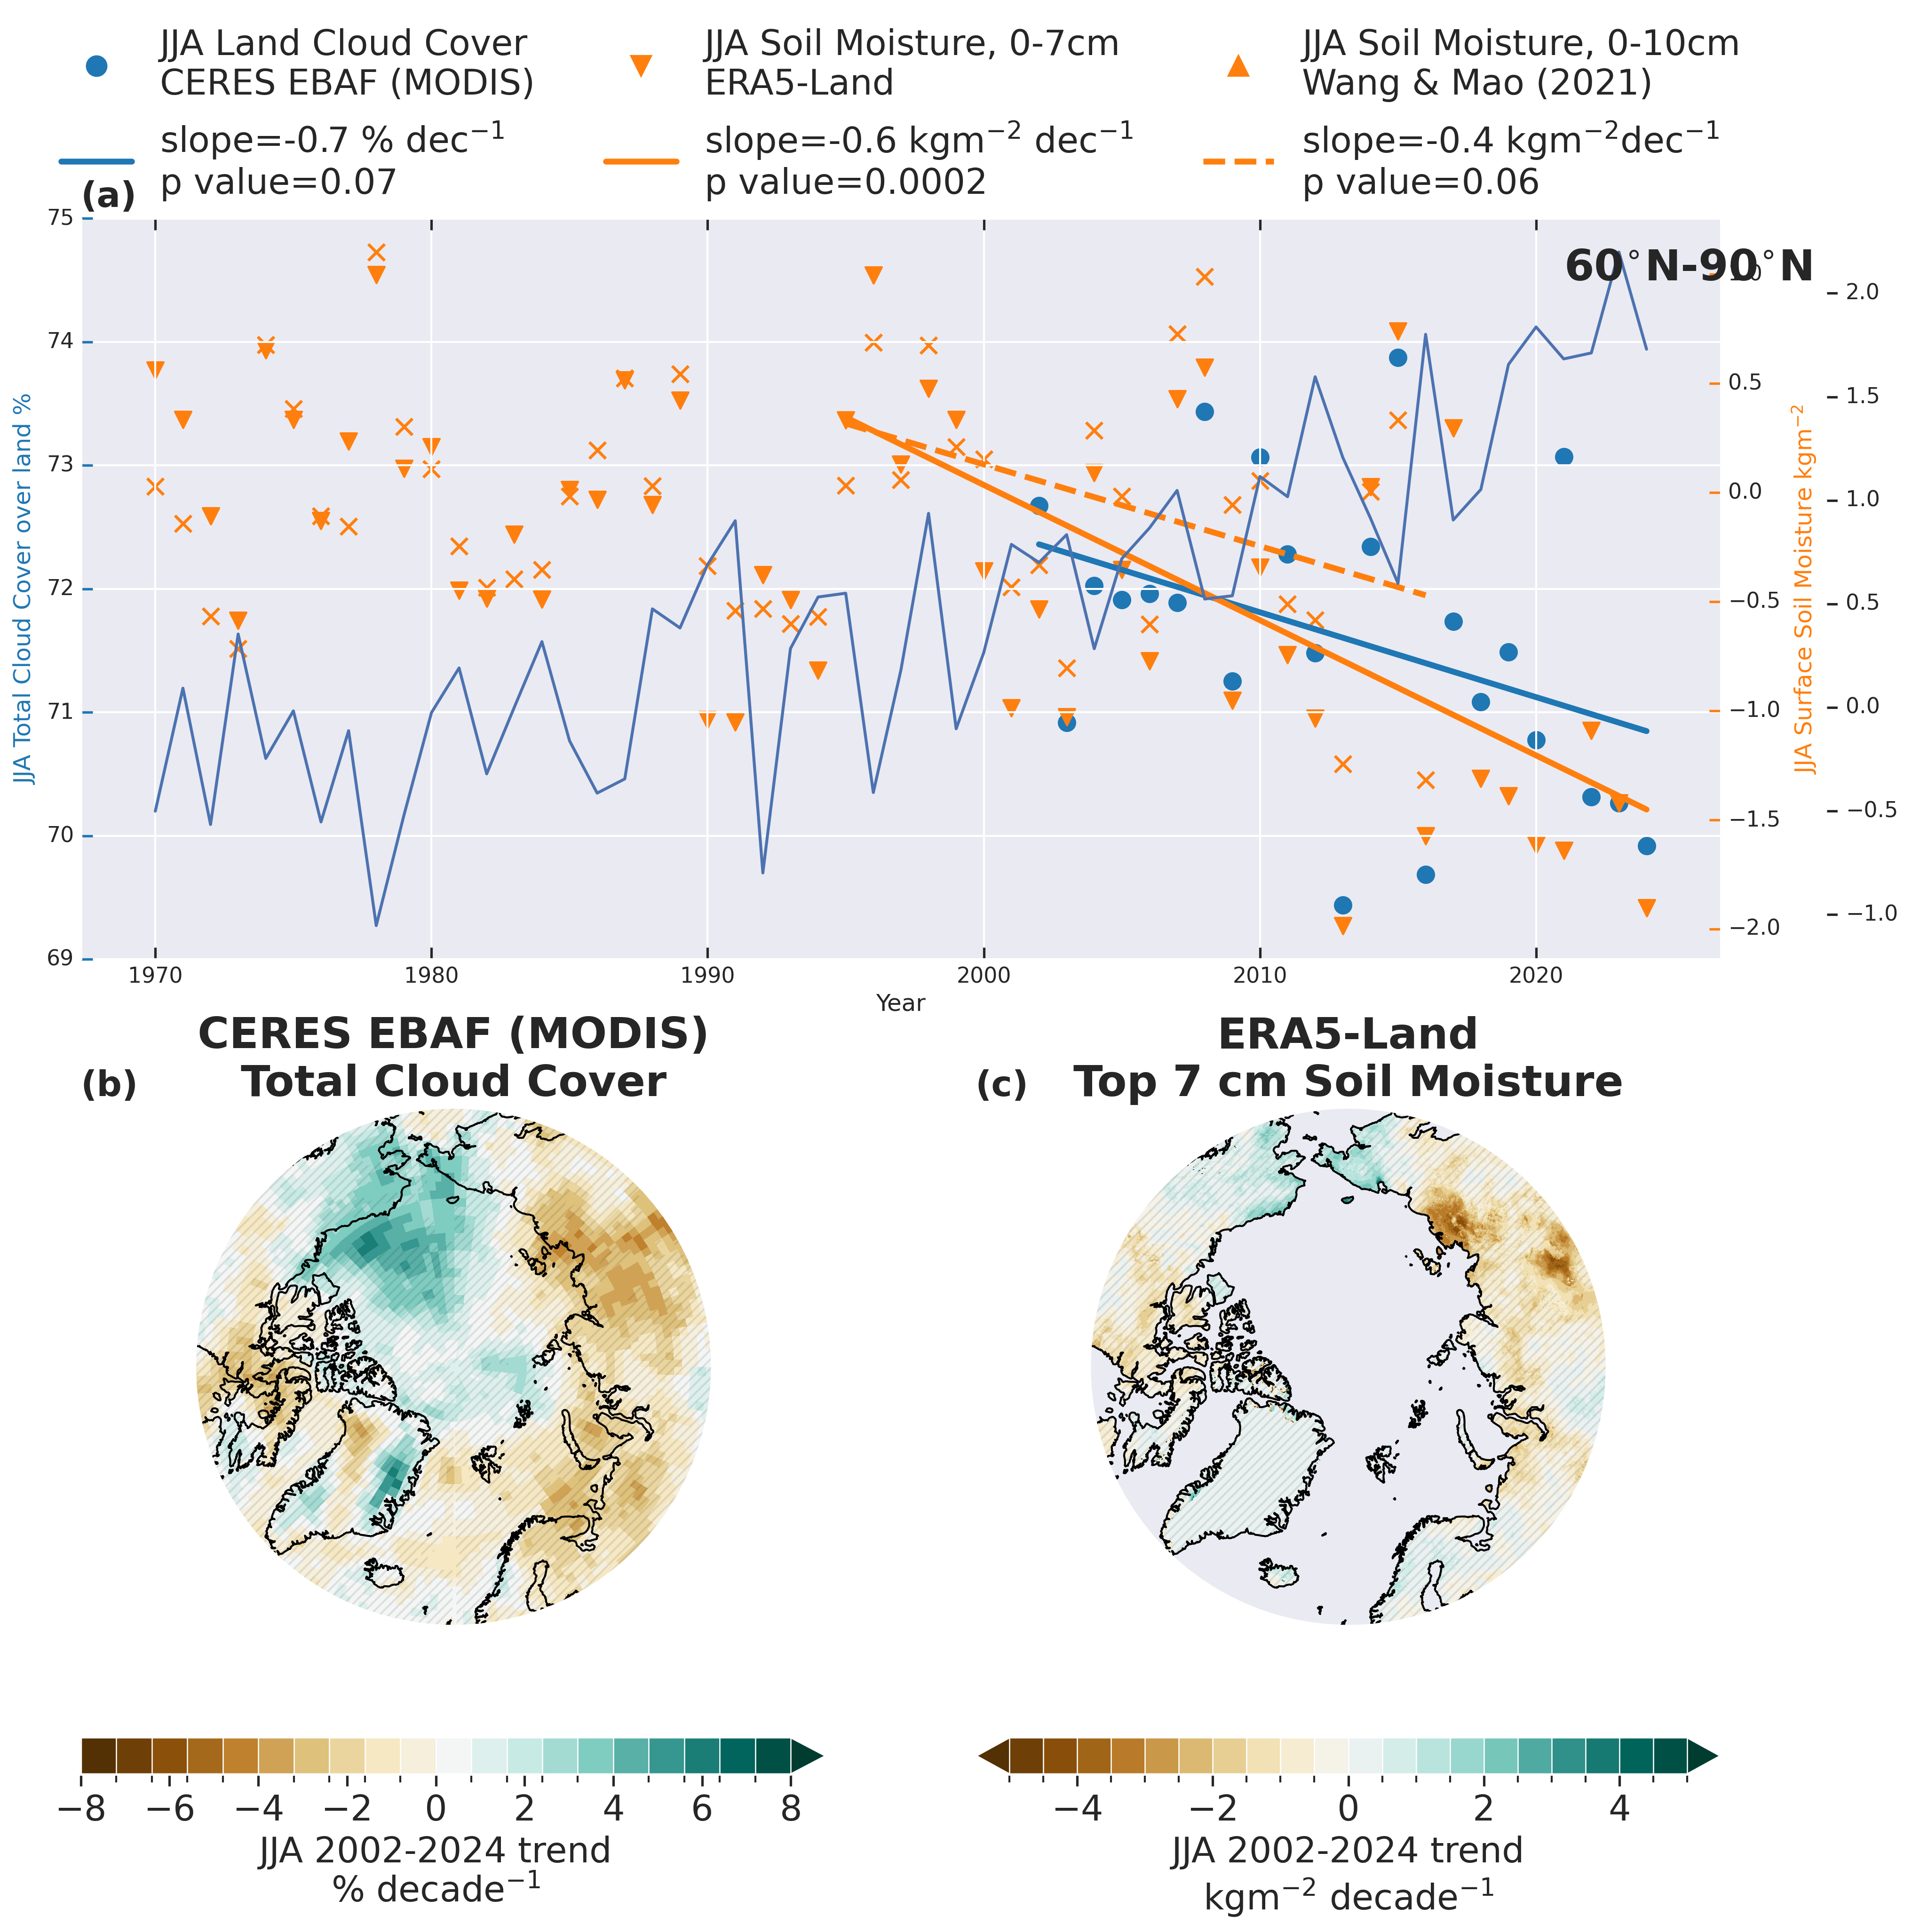

In [115]:
custom_params = {"axes.spines.right": True, "axes.spines.top": True}
sns.set_theme(style="darkgrid", rc=custom_params)
labels = [['(a)','(a)'],['(b)','(c)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 15),dpi=300)
# Remove axis from map plots
for label in labels[1]:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Orthographic(0, 90))
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Orthographic(0, 90))


# Row 1: trends
from mpl_toolkits.axisartist.parasite_axes import HostAxes
axs['(a)'].axis('off')
#ax1 = fig.add_axes([0.1, 0.6, 0.8, 0.4], axes_class=HostAxes)
#ax1 = fig.add_subplot(2, 2, (1,2), axes_class=HostAxes)
ax1 = fig.add_subplot(2, 2, (1,2), axes_class=HostAxes)
ax2 = ax1.get_aux_axes(viewlim_mode=None, sharex=ax1)
ax2_2 = ax1.get_aux_axes(viewlim_mode=None, sharex=ax1)

ax1.axis["right"].set_visible(False)
ax2.axis["right"].set_visible(True)
ax2.axis["right"].major_ticklabels.set_visible(True)
ax2.axis["right"].label.set_visible(True)

ax2_2.axis["right2"] = ax2_2.new_fixed_axis(loc="right", offset=(60, 0))
ax2_2.axis["right"].major_ticklabels.set_visible(True)
ax2_2.axis["right"].label.set_visible(True)

CERES_color='tab:blue'
for i in range(0, len(CERES_season_annual.year)):
    ax1.scatter(CERES_season_annual.year[i], CERES_season_annual.isel(year=i), color=CERES_color, s=70)
ax1.plot(CERES_season_annual.year, CERES_intercept+CERES_slope*CERES_season_annual.year, color=CERES_color, lw=3)

SM_color = 'tab:orange'
timeslice=slice(1970,2024)
timeslice_trend=slice(1995,2024)
for i in range(0, len(SM_ERA5_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_ERA5_season_annual.sel(year=timeslice).year[i], (SM_ERA5_season_annual.sel(year=timeslice)-SM_ERA5_ref_mean).isel(year=i), color=SM_color, marker='v',s=70)
ax2.plot(SM_ERA5_season_annual.sel(year=timeslice_trend).year, SM_ERA5_intercept+SM_ERA5_slope*SM_ERA5_season_annual.sel(year=timeslice_trend).year, color=SM_color, lw=3)

timeslice=slice(1970,2016)
timeslice_trend=slice(1995,2016)
for i in range(0, len(SM_WM_season_annual.sel(year=timeslice).year)):
    ax2.scatter(SM_WM_season_annual.sel(year=timeslice).year[i], (SM_WM_season_annual.sel(year=timeslice)-SM_WM_ref_mean).isel(year=i), color=SM_color, marker='x', s=70)
ax2.plot(SM_WM_season_annual.sel(year=timeslice_trend).year, SM_WM_intercept+SM_WM_slope*SM_WM_season_annual.sel(year=timeslice_trend).year, color=SM_color, ls='--',lw=3)

#years = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
years = [1970, 1980, 1990, 2000, 2010, 2020]
ax1.set_xticks(years)
ax1.set_xticklabels([str(year) for year in years], fontsize=18)


legend_elements = [Line2D([0], [0], marker='o',color='None',mec=CERES_color,mfc=CERES_color, markersize=10, label='JJA Land Cloud Cover\nCERES EBAF (MODIS)'),
                   Line2D([0], [0], color=CERES_color, lw=3, linestyle='-', label='slope='+str(np.round(CERES_slope*10,1))+' % dec$^{-1}$\np value='+str(np.round(CERES_p_value,2))),
                   Line2D([0], [0], marker='v',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Soil Moisture, 0-7cm\nERA5-Land'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='-', label='slope='+str(np.round(SM_ERA5_slope*10,1))+' kgm$^{-2}$ dec$^{-1}$\np value='+str(np.round(SM_ERA5_p_value,4))),
                   Line2D([0], [0], marker='^',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Soil Moisture, 0-10cm\nWang & Mao (2021)'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='--', label='slope='+str(np.round(SM_WM_slope*10,1))+' kgm$^{-2} $dec$^{-1}$\np value='+str(np.round(SM_WM_p_value,2))),]


ax1.text(2021, 74.5, '60$^{\circ}$N-90$^{\circ}$N', fontsize=22, fontweight='bold')
ax1.set_xlabel('Year', fontsize=18)
ax1.set_ylabel('JJA Total Cloud Cover over land %', fontsize=18)
ax1.yaxis.label.set_color(CERES_color)
ax1.tick_params(axis='y', colors=CERES_color)
ax1.set_ylim([69, 75])
yticks1 = [69, 70, 71, 72, 73, 74, 75]
ax1.set_yticks(yticks1)
ax1.set_yticklabels([str(x) for x in yticks1], fontsize=18)

ax2.set_xlabel('Year')
ax2.set_ylabel('JJA Surface Soil Moisture kgm$^{-2}$', fontsize=18)
ax2.yaxis.label.set_color(SM_color)
ax2.tick_params(axis='y', colors=SM_color)
#ax2.set_ylim([22, 34])
#ax2.set_yticks([22, 24, 26, 28, 30, 32, 34])
#ax2.set_yticklabels([22, 24, 26, 28, 30, 32, 34], fontsize=18)
#ax2.grid()

ax1.legend(handles=legend_elements, ncols=3, loc='upper center', 
    bbox_to_anchor=(0.5, 1.3),frameon=False, fontsize=18)

temp_ERA5_JJA = xr.open_dataset(rpath+'temperature2m_ERA5_JJA_annual.nc')
temp_ref_mean = temp_ERA5_JJA['t2m'].sel(year=slice(1970,2000)).mean('year')
ax2_2.plot(np.arange(1970,2025,1),(temp_ERA5_JJA['t2m'].sel(year=slice(1970,2024))-temp_ref_mean))

# Row 2: spatial trends
for ax, title, unit, file, limit in zip([ax3, ax4], 
                                  ['CERES EBAF (MODIS)\nTotal Cloud Cover', 'ERA5-Land\nTop 7 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['CERES_trends_JJA.nc', 'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024_correct.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend'].T*10 # multiply by 10 to get trend per decade
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T > significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'/', hatch_density*'/'])    
    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2002-2024 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')

In [13]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/'
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')

from scipy import stats
for season in ["JJA"]:
    ds_season = CERES['cldarea_total_daynight_mon'].sel(time=CERES.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

    trends = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    p_values = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    for ilon in range(len(CERES.lon)):
        for ilat in range(len(CERES.lat)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(ds_annual.year, ds_annual.isel(lon=ilon, lat=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'lon':CERES.lon, 'lat':CERES.lat}, trends)
    ds_annual['p_value'] = ({'lon':CERES.lon, 'lat':CERES.lat}, p_values)

    ds_annual.to_netcdf(rpath+"CERES_trends_"+season+".nc")

In [6]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')

datadir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'
landfrac = xr.open_dataarray(datadir+'LANDFRAC_piClim.nc')
landmask = landfrac.isel(time=0)
oceanmask = 1-landmask

# Interpolate to 
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
landmask_CERES = landmask_CERES.where(landmask_CERES>=0)
landmask_CERES = landmask_CERES.fillna(0)

oceanmask_CERES = 1-landmask_CERES

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+".nc")

In [70]:
var = 'swvl1'
ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+".nc")


In [75]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(2002,2024)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(2002,2024)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2024.nc")


In [25]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
var='swvl1'

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(1970,2016)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(1970,2016)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_1970_2016.nc")


In [4]:
season="JJA"
rpath = "/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
ds_annual = xr.open_dataset(rpath+"SM_ERA5_trends_"+season+".nc")
ds_annual = ds_annual.reindex(latitude=list(reversed(ds_annual.latitude)))

In [4]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'
ds_SM_WM = xr.open_dataset(filepath)

In [11]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = ds_SM_WM.sel(time=ds_SM_WM.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

    trends = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    p_values = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    for ilat in range(len(ds_SM_WM.lat)):
        for ilon in range(len(ds_SM_WM.lon)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(ds_annual.year, ds_annual['mrsos'].isel(lat=ilat, lon=ilon))
            trends[ilat, ilon] = slope
            p_values[ilat, ilon] = p_value
    
    ds_annual['trend'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, trends)
    ds_annual['p_value'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, p_values)

    ds_annual.to_netcdf(savedir+"SM_WM_trends_"+season+".nc")

In [19]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = ds_SM_WM.sel(time=ds_SM_WM.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

    trends = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    p_values = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    for ilat in range(len(ds_SM_WM.lat)):
        for ilon in range(len(ds_SM_WM.lon)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(ds_annual.year.sel(year=slice(1994,2016)), ds_annual['mrsos'].isel(lat=ilat, lon=ilon).sel(year=slice(1994,2016)))
            trends[ilat, ilon] = slope
            p_values[ilat, ilon] = p_value
    
    ds_annual['trend'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, trends)
    ds_annual['p_value'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, p_values)

    ds_annual.to_netcdf(savedir+"SM_WM_trends_"+season+"_1994_2016.nc")

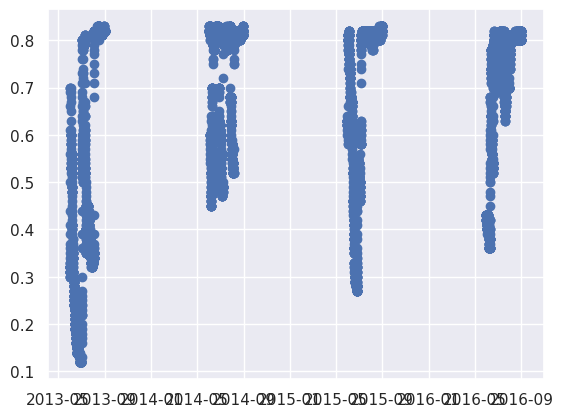

In [156]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
folder = 'ISMN_data_Arctic_1951_2025'
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ISMN_data_Arctic_1951_2025/FMI/SODAWS/FMI_FMI_SODAWS_sm_0.100000_0.100000_ThetaProbe-ML2X-A_19510403_20251212.stm'
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ISMN_data_Arctic_1951_2025/SCAN/SchorGarden/SCAN_SCAN_SchorGarden_sm_0.254000_0.254000_Hydraprobe-Analog-A_19510403_20251212.stm'
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ISMN_data_Arctic_1951_2025/FMI/SAA120/FMI_FMI_SAA120_sm_0.050000_0.050000_5TE-B_19510403_20251212.stm'
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ISMN_data_Arctic_1951_2025/FMI/SOD140/FMI_FMI_SOD140_sm_0.050000_0.050000_CS655-A_19510403_20251212.stm'
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ISMN_data_Arctic_1951_2025/SCAN/LowerMulchatna/SCAN_SCAN_LowerMulchatna_sm_0.050800_0.050800_n.s.-A_19510403_20251212.stm'


import pandas as pd
ds = pd.read_csv(filepath,sep=' ',skiprows=1,names=['Date','Time (UTC)','Soil moisture','Flag1','Flag2'],index_col=0)
with open(filepath) as file:
    first_line = file.readline()
first_line = first_line.split(' ')
header = []
for elem in first_line:
    if elem != '':
        header.append(elem)

ds.index = pd.to_datetime(ds.index)
JJA = ds[(ds.index.month > 5) & (ds.index.month < 9)]
plt.scatter(JJA.index, JJA['Soil moisture'])